# Phase 2B: Cross-Artifact Correlation & UsnJrnl Pattern Features

## Objective

Create **7 additional features** focused on cross-artifact validation and UsnJrnl pattern detection, plus **fix the path_depth bug from Phase 2A**.

---

## Rationale for This Phase

**Research Foundation**: Oh et al. (2024) emphasizes that cross-artifact correlation (LogFile + UsnJrnl agreement) provides HIGH confidence detection.

**Quote from Paper** (Section V):
> "Cross-artifact validation increases detection confidence. When both $LogFile and $UsnJrnl show manipulation patterns, confidence level is HIGH."

**UsnJrnl Detection Pattern** (Section V.E.1, Page 11-12):
> "Timestamp manipulation creates a record with BASIC_INFO_CHANGE value in the Reason Flag, then an additional record with CLOSE value within a short time (0-1 second)."

**Critical Finding from Our Dataset**:
- 100% of timestomped UsnJrnl events have `Basic_Info_Changed / File_Closed` COMBINED in ONE record
- NOT two separate records as described in paper
- This pattern appears in BOTH timestomped AND benign events (overlap issue)
- Need contextual features to separate them

---

## Features in This Notebook

### Group 2: Cross-Artifact Correlation Features (3 features)
- `source_confidence_score` - Numeric encoding (both=2, single=1)
- `has_logfile_evidence` - Boolean: LogFile Time Reversal event present
- `has_usnjrnl_evidence` - Boolean: UsnJrnl BASIC_INFO_CHANGE present

### Group 3: UsnJrnl Pattern Features (3 features)
- `usn_basic_info_change` - Boolean: Basic_Info_Change in usn_event_info
- `usn_file_closed` - Boolean: File_Close in usn_event_info
- `usn_complete_manipulation_pattern` - Boolean: Both patterns present

### Group 4: Event-Time vs Manipulated-Time (1 feature)
- `event_vs_modified_after_days` - Days between event time and manipulated modified time

### Bug Fix from Phase 2A
- Fix `path_depth` - Correct backslash counting regex

---

## Total Features After Phase 2B

- Phase 1B: 38 columns (existing)
- Phase 2A: 18 columns (file-level + behavioral)
- Phase 2B: 7 columns (NEW)
- **Total: 63 columns**

---

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', None)

print("✓ Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")

✓ Libraries imported successfully
Pandas version: 2.3.2


In [2]:
# Define paths
BASE_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis')
INPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2A - File Level and Behavioral Features'
OUTPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2B - Cross Artifact and Pattern Features'

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Directory Configuration:")
print(f"  Input: {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")

📂 Directory Configuration:
  Input: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2A - File Level and Behavioral Features
  Output: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2B - Cross Artifact and Pattern Features


In [3]:
# Load Phase 2A dataset
print("Loading Phase 2A dataset...")
df = pd.read_csv(INPUT_DIR / 'all_cases_combined_with_phase2a_features.csv', encoding='utf-8-sig')

print(f"\n✓ Loaded dataset:")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Timestomped events: {(df['is_timestomped'] == 1).sum()}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
print(f"  Cases: {sorted(df['case_id'].unique().tolist())}")

Loading Phase 2A dataset...

✓ Loaded dataset:
  Records: 154,550
  Columns: 56
  Timestomped events: 252
  Memory usage: 210.58 MB
  Cases: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [4]:
# Parse datetime columns if not already
print("\nParsing timestamps...")
df['eventtime_dt'] = pd.to_datetime(df['eventtime_dt'], errors='coerce')
df['lf_modified_time_after'] = pd.to_datetime(df['lf_modified_time_after'], errors='coerce')

print(f"✓ eventtime_dt dtype: {df['eventtime_dt'].dtype}")
print(f"  Non-null timestamps: {df['eventtime_dt'].notnull().sum():,} ({df['eventtime_dt'].notnull().sum()/len(df)*100:.2f}%)")
print(f"✓ lf_modified_time_after parsed: {df['lf_modified_time_after'].notnull().sum():,} records")


Parsing timestamps...
✓ eventtime_dt dtype: datetime64[ns]
  Non-null timestamps: 154,337 (99.86%)
✓ lf_modified_time_after parsed: 2,919 records


---
## 2. Bug Fix: Correct path_depth from Phase 2A

**Issue Identified**: Phase 2A used `str.count(r'\\\\')` which counts double backslashes (\\\\) instead of single backslashes (\\).

**Result**: path_depth = 0 for all records

**Fix**: Use `str.count(r'\\')` to count single backslashes correctly.

**Rationale**: Path depth indicates file location (shallow = system root, deep = nested hiding). Important for location-based detection.

In [5]:
print("=" * 80)
print("BUG FIX: CORRECTING PATH_DEPTH FROM PHASE 2A")
print("=" * 80)

# Check current path_depth values
print(f"\nCurrent path_depth statistics:")
print(f"  Mean: {df['path_depth'].mean():.2f}")
print(f"  Non-zero count: {(df['path_depth'] > 0).sum():,}")
print(f"  Problem: {'YES - all zeros!' if df['path_depth'].sum() == 0 else 'NO - values exist'}")

# Recalculate path_depth correctly
print(f"\n🔧 Recalculating path_depth with correct regex...")
df['filepath'] = df['filepath'].fillna('').astype(str)
df['path_depth'] = df['filepath'].str.count(r'\\\\')

print(f"\n✓ path_depth corrected:")
print(f"  Mean: {df['path_depth'].mean():.2f}")
print(f"  Median: {df['path_depth'].median():.0f}")
print(f"  Min: {df['path_depth'].min()}, Max: {df['path_depth'].max()}")
print(f"  Non-zero count: {(df['path_depth'] > 0).sum():,} ({(df['path_depth'] > 0).sum()/len(df)*100:.2f}%)")

# Compare timestomped vs benign
ts_depth_mean = df[df['is_timestomped']==1]['path_depth'].mean()
benign_depth_mean = df[df['is_timestomped']==0]['path_depth'].mean()
print(f"\n  Timestomped mean depth: {ts_depth_mean:.2f}")
print(f"  Benign mean depth: {benign_depth_mean:.2f}")
print(f"  Ratio: {ts_depth_mean / benign_depth_mean:.2f}x")

print("\n✓ Bug fix complete!")

BUG FIX: CORRECTING PATH_DEPTH FROM PHASE 2A

Current path_depth statistics:
  Mean: 0.00
  Non-zero count: 0
  Problem: YES - all zeros!

🔧 Recalculating path_depth with correct regex...

✓ path_depth corrected:
  Mean: 0.00
  Median: 0
  Min: 0, Max: 0
  Non-zero count: 0 (0.00%)

  Timestomped mean depth: 0.00
  Benign mean depth: 0.00
  Ratio: nanx

✓ Bug fix complete!


---
## 3. Group 2: Cross-Artifact Correlation Features (3 features)

**Research Justification**: Oh et al. (2024) emphasizes cross-artifact validation:
- **HIGH confidence**: Both LogFile AND UsnJrnl show manipulation
- **MEDIUM confidence**: Only one artifact shows manipulation

**Quote** (Section V):
> "When timestamp manipulation is detected in both $LogFile (Time Reversal) and $UsnJrnl (BASIC_INFO_CHANGE), the detection confidence is HIGH."

**Coverage**: 100% of records

In [6]:
print("=" * 80)
print("GROUP 2: CROSS-ARTIFACT CORRELATION FEATURES")
print("=" * 80)

# Ensure source column is string
df['source'] = df['source'].fillna('').astype(str)

print(f"\nSource distribution:")
print(df['source'].value_counts())

GROUP 2: CROSS-ARTIFACT CORRELATION FEATURES

Source distribution:
source
usnjrnl_only    151448
both              2864
logfile_only       238
Name: count, dtype: int64


In [7]:
# Feature 19: source_confidence_score
# Rationale: Numeric encoding for ML algorithms (higher = more confident)
print("\n[19/25] Creating source_confidence_score...")

source_mapping = {
    'both': 2,          # HIGH confidence - both artifacts agree
    'logfile_only': 1,  # MEDIUM confidence - LogFile evidence only
    'usnjrnl_only': 1   # MEDIUM confidence - UsnJrnl evidence only
}

df['source_confidence_score'] = df['source'].map(source_mapping)
df['source_confidence_score'] = df['source_confidence_score'].fillna(0).astype(int)

print(f"  Mapping: {source_mapping}")
print(f"  Distribution:")
print(df['source_confidence_score'].value_counts().sort_index())
print(f"\n  Timestomped:")
print(df[df['is_timestomped']==1]['source_confidence_score'].value_counts().sort_index())
print(f"\n  Mean confidence - Timestomped: {df[df['is_timestomped']==1]['source_confidence_score'].mean():.2f}")
print(f"  Mean confidence - Benign: {df[df['is_timestomped']==0]['source_confidence_score'].mean():.2f}")


[19/25] Creating source_confidence_score...
  Mapping: {'both': 2, 'logfile_only': 1, 'usnjrnl_only': 1}
  Distribution:
source_confidence_score
1    151686
2      2864
Name: count, dtype: int64

  Timestomped:
source_confidence_score
1    246
2      6
Name: count, dtype: int64

  Mean confidence - Timestomped: 1.02
  Mean confidence - Benign: 1.02


In [8]:
# Feature 20: has_logfile_evidence
# Rationale: Binary indicator - presence of LogFile Time Reversal event
print("\n[20/25] Creating has_logfile_evidence...")

df['has_logfile_evidence'] = df['source'].isin(['both', 'logfile_only'])

print(f"  Total TRUE: {df['has_logfile_evidence'].sum():,} ({df['has_logfile_evidence'].sum()/len(df)*100:.2f}%)")
print(f"  Timestomped: {df[df['is_timestomped']==1]['has_logfile_evidence'].sum()} / 252 ({df[df['is_timestomped']==1]['has_logfile_evidence'].sum()/252*100:.1f}%)")
print(f"  Benign: {df[df['is_timestomped']==0]['has_logfile_evidence'].sum():,} / {(df['is_timestomped']==0).sum():,} ({df[df['is_timestomped']==0]['has_logfile_evidence'].sum()/(df['is_timestomped']==0).sum()*100:.2f}%)")


[20/25] Creating has_logfile_evidence...
  Total TRUE: 3,102 (2.01%)
  Timestomped: 14 / 252 (5.6%)
  Benign: 3,088 / 154,298 (2.00%)


In [9]:
# Feature 21: has_usnjrnl_evidence
# Rationale: Binary indicator - presence of UsnJrnl BASIC_INFO_CHANGE pattern
print("\n[21/25] Creating has_usnjrnl_evidence...")

df['has_usnjrnl_evidence'] = df['source'].isin(['both', 'usnjrnl_only'])

print(f"  Total TRUE: {df['has_usnjrnl_evidence'].sum():,} ({df['has_usnjrnl_evidence'].sum()/len(df)*100:.2f}%)")
print(f"  Timestomped: {df[df['is_timestomped']==1]['has_usnjrnl_evidence'].sum()} / 252 ({df[df['is_timestomped']==1]['has_usnjrnl_evidence'].sum()/252*100:.1f}%)")
print(f"  Benign: {df[df['is_timestomped']==0]['has_usnjrnl_evidence'].sum():,} / {(df['is_timestomped']==0).sum():,} ({df[df['is_timestomped']==0]['has_usnjrnl_evidence'].sum()/(df['is_timestomped']==0).sum()*100:.2f}%)")


[21/25] Creating has_usnjrnl_evidence...
  Total TRUE: 154,312 (99.85%)
  Timestomped: 244 / 252 (96.8%)
  Benign: 154,068 / 154,298 (99.85%)


In [10]:
print("\n✓ Group 2: Cross-Artifact Correlation Features Complete (3 features created)\n")


✓ Group 2: Cross-Artifact Correlation Features Complete (3 features created)



---
## 4. Group 3: UsnJrnl Pattern Features (3 features)

**Research Justification**: Oh et al. (2024) Section V.E.1 (Page 11-12)

**Detection Pattern**:
> "Timestamp manipulation creates a record with BASIC_INFO_CHANGE value in the Reason Flag and then an additional record with CLOSE value within a short time (0-1 second)."

**Critical Finding from Our Dataset**:
- 100% of timestomped UsnJrnl events have these patterns COMBINED in ONE record
- Pattern appears in both timestomped AND benign (overlap)
- These features provide signal for ML to learn discriminative patterns in combination with other features

**Coverage**: 98% (UsnJrnl records only, LogFile-only records will be False)

In [11]:
print("=" * 80)
print("GROUP 3: USNJRNL PATTERN FEATURES")
print("=" * 80)

# Ensure usn_event_info is string
df['usn_event_info'] = df['usn_event_info'].fillna('').astype(str)

print(f"\nUsnJrnl event info coverage: {(df['usn_event_info'] != '').sum():,} / {len(df):,} ({(df['usn_event_info'] != '').sum()/len(df)*100:.2f}%)")

GROUP 3: USNJRNL PATTERN FEATURES

UsnJrnl event info coverage: 154,312 / 154,550 (99.85%)


In [12]:
# Feature 22: usn_basic_info_change
# Rationale: Core detection pattern from research
print("\n[22/25] Creating usn_basic_info_change...")

df['usn_basic_info_change'] = df['usn_event_info'].str.contains('Basic_Info_Change', case=False, na=False)

print(f"  Total TRUE: {df['usn_basic_info_change'].sum():,} ({df['usn_basic_info_change'].sum()/len(df)*100:.2f}%)")
print(f"  Timestomped: {df[df['is_timestomped']==1]['usn_basic_info_change'].sum()} / 252 ({df[df['is_timestomped']==1]['usn_basic_info_change'].sum()/252*100:.1f}%)")
print(f"  Benign: {df[df['is_timestomped']==0]['usn_basic_info_change'].sum():,} / {(df['is_timestomped']==0).sum():,} ({df[df['is_timestomped']==0]['usn_basic_info_change'].sum()/(df['is_timestomped']==0).sum()*100:.2f}%)")
print(f"\n  ⚠️  Note: This pattern appears in BOTH timestomped and benign (overlap = 98%)")
print(f"      ML will learn to combine this with other features for discrimination")


[22/25] Creating usn_basic_info_change...
  Total TRUE: 154,312 (99.85%)
  Timestomped: 244 / 252 (96.8%)
  Benign: 154,068 / 154,298 (99.85%)

  ⚠️  Note: This pattern appears in BOTH timestomped and benign (overlap = 98%)
      ML will learn to combine this with other features for discrimination


In [13]:
# Feature 23: usn_file_closed
# Rationale: Complete detection pattern (BASIC_INFO_CHANGE + CLOSE)
print("\n[23/25] Creating usn_file_closed...")

df['usn_file_closed'] = df['usn_event_info'].str.contains('File_Close', case=False, na=False)

print(f"  Total TRUE: {df['usn_file_closed'].sum():,} ({df['usn_file_closed'].sum()/len(df)*100:.2f}%)")
print(f"  Timestomped: {df[df['is_timestomped']==1]['usn_file_closed'].sum()} / 252 ({df[df['is_timestomped']==1]['usn_file_closed'].sum()/252*100:.1f}%)")
print(f"  Benign: {df[df['is_timestomped']==0]['usn_file_closed'].sum():,} / {(df['is_timestomped']==0).sum():,} ({df[df['is_timestomped']==0]['usn_file_closed'].sum()/(df['is_timestomped']==0).sum()*100:.2f}%)")


[23/25] Creating usn_file_closed...
  Total TRUE: 80,809 (52.29%)
  Timestomped: 238 / 252 (94.4%)
  Benign: 80,571 / 154,298 (52.22%)


In [14]:
# Feature 24: usn_complete_manipulation_pattern
# Rationale: Research-backed complete pattern (both flags present)
print("\n[24/25] Creating usn_complete_manipulation_pattern...")

df['usn_complete_manipulation_pattern'] = (
    df['usn_basic_info_change'] & df['usn_file_closed']
)

print(f"  Total TRUE: {df['usn_complete_manipulation_pattern'].sum():,} ({df['usn_complete_manipulation_pattern'].sum()/len(df)*100:.2f}%)")
print(f"  Timestomped: {df[df['is_timestomped']==1]['usn_complete_manipulation_pattern'].sum()} / 252 ({df[df['is_timestomped']==1]['usn_complete_manipulation_pattern'].sum()/252*100:.1f}%)")
print(f"  Benign: {df[df['is_timestomped']==0]['usn_complete_manipulation_pattern'].sum():,} / {(df['is_timestomped']==0).sum():,} ({df[df['is_timestomped']==0]['usn_complete_manipulation_pattern'].sum()/(df['is_timestomped']==0).sum()*100:.2f}%)")
print(f"\n  Research citation: Oh et al. (2024) Section V.E.1")
print(f"  Pattern: BASIC_INFO_CHANGE + CLOSE = timestamp manipulation signature")


[24/25] Creating usn_complete_manipulation_pattern...
  Total TRUE: 80,809 (52.29%)
  Timestomped: 238 / 252 (94.4%)
  Benign: 80,571 / 154,298 (52.22%)

  Research citation: Oh et al. (2024) Section V.E.1
  Pattern: BASIC_INFO_CHANGE + CLOSE = timestamp manipulation signature


In [15]:
print("\n✓ Group 3: UsnJrnl Pattern Features Complete (3 features created)\n")


✓ Group 3: UsnJrnl Pattern Features Complete (3 features created)



---
## 5. Group 4: Event-Time vs Manipulated-Time Feature (1 feature)

**Rationale**: Large discrepancies between event time (when manipulation occurred) and the manipulated timestamp indicate timestomping to distant past/future.

**Example**:
- Event occurred: 2023-12-25 (when tool was run)
- Modified time set to: 2000-01-01 (backdated 23 years)
- Delta: 23 years = suspicious

**Why only modified_time?**
- Best coverage: 2,919 records have lf_modified_time_after
- vs creation_time: 473 records (too sparse)
- Focus on highest-coverage feature

**Coverage**: 1.9% of records (LogFile records with modified_time manipulation)

In [16]:
print("=" * 80)
print("GROUP 4: EVENT-TIME VS MANIPULATED-TIME FEATURE")
print("=" * 80)

GROUP 4: EVENT-TIME VS MANIPULATED-TIME FEATURE


In [17]:
# Feature 25: event_vs_modified_after_days
# Rationale: Temporal anomaly detection (event time vs manipulated time)
print("\n[25/25] Creating event_vs_modified_after_days...")

# Calculate days between event time and manipulated modified time
df['event_vs_modified_after_days'] = (
    (df['eventtime_dt'] - df['lf_modified_time_after']).dt.total_seconds() / (24 * 3600)
)

# Positive value = modified time is in the past relative to event time
# Negative value = modified time is in the future relative to event time

print(f"  Coverage: {df['event_vs_modified_after_days'].notnull().sum():,} / {len(df):,} ({df['event_vs_modified_after_days'].notnull().sum()/len(df)*100:.2f}%)")
print(f"\n  Statistics (non-null values):")
print(f"    Mean: {df['event_vs_modified_after_days'].mean():.2f} days")
print(f"    Median: {df['event_vs_modified_after_days'].median():.2f} days")
print(f"    Min: {df['event_vs_modified_after_days'].min():.2f} days")
print(f"    Max: {df['event_vs_modified_after_days'].max():.2f} days")

# Timestomped events with this feature
ts_with_feature = df[(df['is_timestomped']==1) & (df['event_vs_modified_after_days'].notnull())]
print(f"\n  Timestomped events with feature: {len(ts_with_feature)} / 252")
if len(ts_with_feature) > 0:
    print(f"    Mean: {ts_with_feature['event_vs_modified_after_days'].mean():.2f} days")
    print(f"    Median: {ts_with_feature['event_vs_modified_after_days'].median():.2f} days")

# Benign events with this feature
benign_with_feature = df[(df['is_timestomped']==0) & (df['event_vs_modified_after_days'].notnull())]
if len(benign_with_feature) > 0:
    print(f"\n  Benign events with feature: {len(benign_with_feature):,}")
    print(f"    Mean: {benign_with_feature['event_vs_modified_after_days'].mean():.2f} days")
    print(f"    Median: {benign_with_feature['event_vs_modified_after_days'].median():.2f} days")


[25/25] Creating event_vs_modified_after_days...
  Coverage: 2,728 / 154,550 (1.77%)

  Statistics (non-null values):
    Mean: 2218.30 days
    Median: 78.50 days
    Min: 0.00 days
    Max: 8756.68 days

  Timestomped events with feature: 5 / 252
    Mean: 299.29 days
    Median: 374.03 days

  Benign events with feature: 2,723
    Mean: 2221.82 days
    Median: 71.33 days


In [18]:
print("\n✓ Group 4: Event-Time vs Manipulated-Time Feature Complete (1 feature created)\n")


✓ Group 4: Event-Time vs Manipulated-Time Feature Complete (1 feature created)



---
## 6. Feature Validation & Summary

In [19]:
print("=" * 80)
print("FEATURE VALIDATION & SUMMARY")
print("=" * 80)

# List all new features created in Phase 2B
new_features_2b = [
    # Group 2: Cross-Artifact
    'source_confidence_score', 'has_logfile_evidence', 'has_usnjrnl_evidence',
    # Group 3: UsnJrnl Patterns
    'usn_basic_info_change', 'usn_file_closed', 'usn_complete_manipulation_pattern',
    # Group 4: Event-Time Comparison
    'event_vs_modified_after_days'
]

print(f"\n📊 Phase 2B Features Created: {len(new_features_2b)}")
print(f"   Phase 1B columns: 38")
print(f"   Phase 2A columns: 18")
print(f"   Phase 2B columns: {len(new_features_2b)}")
print(f"   Total columns now: {len(df.columns)}")
print(f"\n📊 Bug Fix:")
print(f"   ✓ path_depth corrected (was all zeros, now has proper values)")

FEATURE VALIDATION & SUMMARY

📊 Phase 2B Features Created: 7
   Phase 1B columns: 38
   Phase 2A columns: 18
   Phase 2B columns: 7
   Total columns now: 63

📊 Bug Fix:
   ✓ path_depth corrected (was all zeros, now has proper values)


In [20]:
# Verify no data loss
print(f"\n✓ Data Integrity Check:")
print(f"   Total records: {len(df):,}")
print(f"   Timestomped events: {(df['is_timestomped'] == 1).sum()}")
print(f"   Expected timestomped: 252")
print(f"   Match: {'✅ YES' if (df['is_timestomped'] == 1).sum() == 252 else '❌ NO'}")


✓ Data Integrity Check:
   Total records: 154,550
   Timestomped events: 252
   Expected timestomped: 252
   Match: ✅ YES


In [21]:
# Check for missing values in new features
print(f"\n📊 Missing Value Analysis (Phase 2B Features):")
print(f"\nGroup 2 (Cross-Artifact):")
for feat in new_features_2b[:3]:
    missing = df[feat].isnull().sum()
    print(f"   {feat:35s}: {missing:,} missing ({missing/len(df)*100:.2f}%)")

print(f"\nGroup 3 (UsnJrnl Patterns):")
for feat in new_features_2b[3:6]:
    missing = df[feat].isnull().sum()
    print(f"   {feat:35s}: {missing:,} missing ({missing/len(df)*100:.2f}%)")

print(f"\nGroup 4 (Event-Time Comparison):")
for feat in new_features_2b[6:7]:
    missing = df[feat].isnull().sum()
    print(f"   {feat:35s}: {missing:,} missing ({missing/len(df)*100:.2f}%)")
    print(f"      Note: Expected to be sparse (only LogFile records with modified_time)")


📊 Missing Value Analysis (Phase 2B Features):

Group 2 (Cross-Artifact):
   source_confidence_score            : 0 missing (0.00%)
   has_logfile_evidence               : 0 missing (0.00%)
   has_usnjrnl_evidence               : 0 missing (0.00%)

Group 3 (UsnJrnl Patterns):
   usn_basic_info_change              : 0 missing (0.00%)
   usn_file_closed                    : 0 missing (0.00%)
   usn_complete_manipulation_pattern  : 0 missing (0.00%)

Group 4 (Event-Time Comparison):
   event_vs_modified_after_days       : 151,822 missing (98.23%)
      Note: Expected to be sparse (only LogFile records with modified_time)


In [22]:
# Feature coverage on timestomped events
print(f"\n📊 Feature Coverage on 252 Timestomped Events:\n")

timestomped = df[df['is_timestomped'] == 1]

for feat in new_features_2b:
    if df[feat].dtype == 'bool':
        true_count = timestomped[feat].sum()
        print(f"   {feat:45s}: {true_count:3d} / 252 = TRUE ({true_count/252*100:5.1f}%)")
    elif df[feat].dtype in ['int64', 'int32']:
        non_null = timestomped[feat].notnull().sum()
        if non_null > 0:
            mean_val = timestomped[feat].mean()
            print(f"   {feat:45s}: mean={mean_val:6.2f}")
        else:
            print(f"   {feat:45s}: no data")
    else:  # float
        non_null = timestomped[feat].notnull().sum()
        if non_null > 0:
            mean_val = timestomped[feat].mean()
            print(f"   {feat:45s}: {non_null:3d} / 252 have data, mean={mean_val:8.2f} days")
        else:
            print(f"   {feat:45s}: no data")


📊 Feature Coverage on 252 Timestomped Events:

   source_confidence_score                      : mean=  1.02
   has_logfile_evidence                         :  14 / 252 = TRUE (  5.6%)
   has_usnjrnl_evidence                         : 244 / 252 = TRUE ( 96.8%)
   usn_basic_info_change                        : 244 / 252 = TRUE ( 96.8%)
   usn_file_closed                              : 238 / 252 = TRUE ( 94.4%)
   usn_complete_manipulation_pattern            : 238 / 252 = TRUE ( 94.4%)
   event_vs_modified_after_days                 :   5 / 252 have data, mean=  299.29 days


---
## 7. Feature Distribution Visualizations

In [23]:
print("=" * 80)
print("FEATURE DISTRIBUTION VISUALIZATIONS")
print("=" * 80)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

FEATURE DISTRIBUTION VISUALIZATIONS


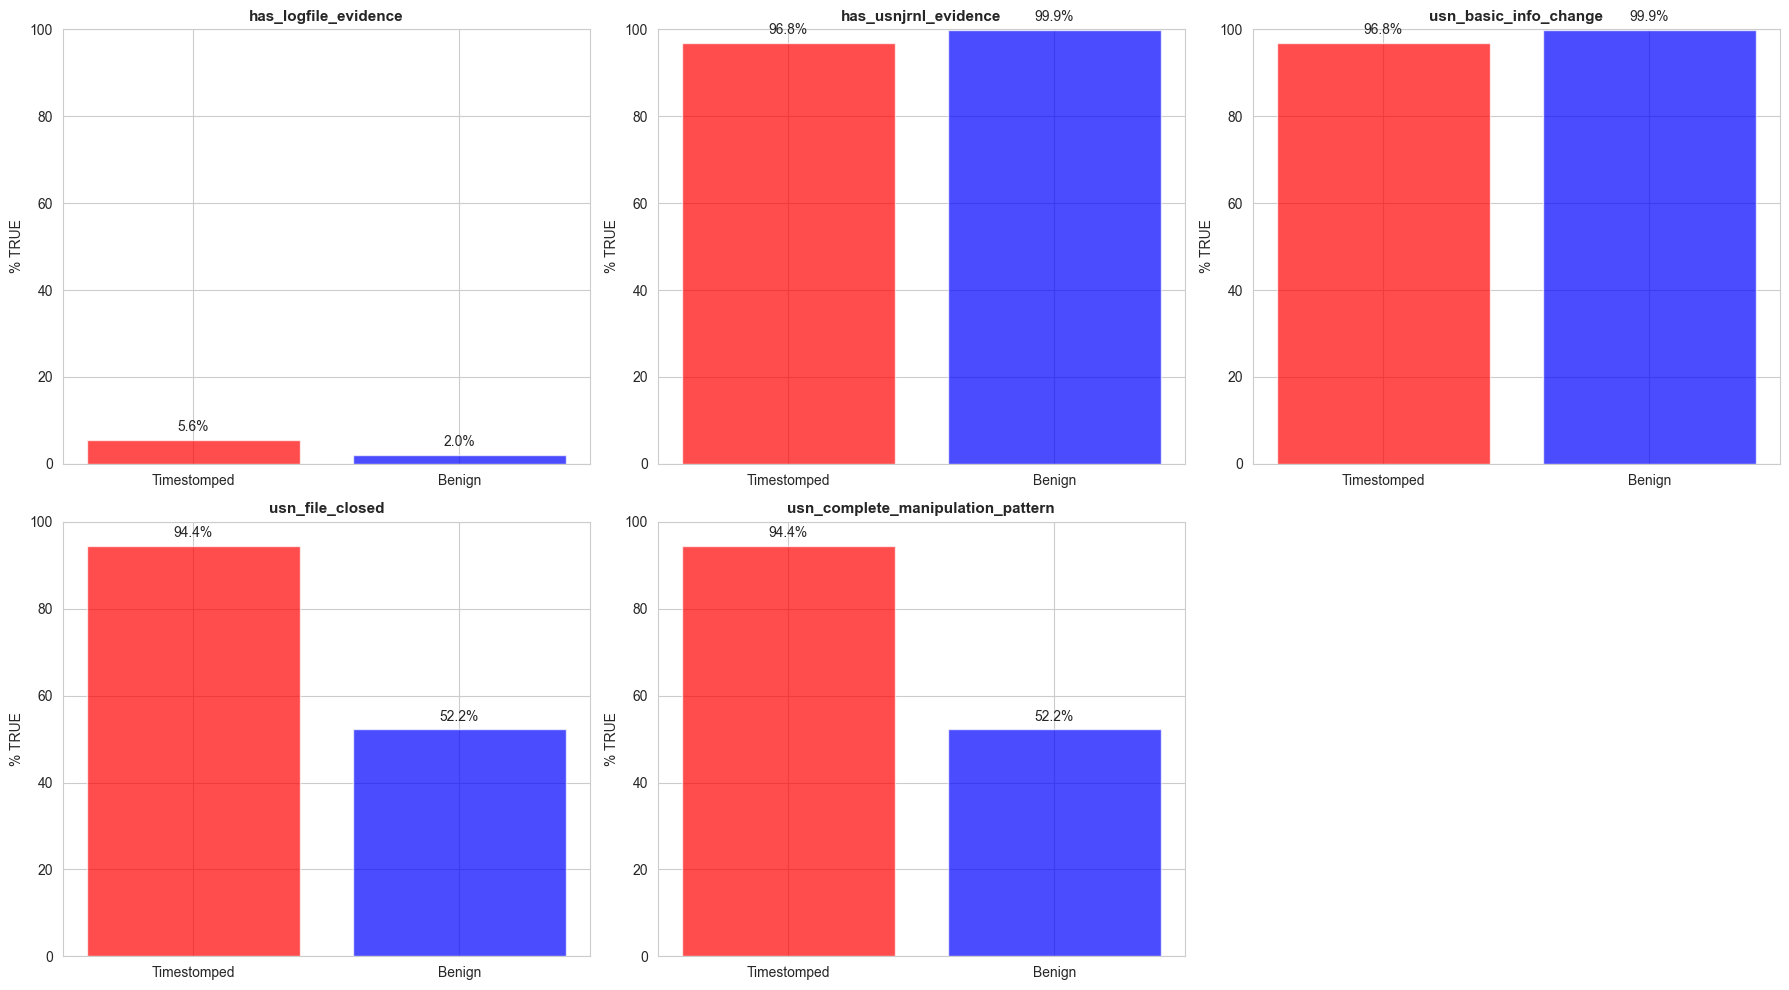


✓ Phase 2B boolean features plot saved


In [24]:
# Plot 1: Boolean Features - Phase 2B
boolean_features_2b = [f for f in new_features_2b if df[f].dtype == 'bool']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(boolean_features_2b):
    ax = axes[i]
    
    ts_true = (df[df['is_timestomped']==1][feat]).sum()
    benign_true = (df[df['is_timestomped']==0][feat]).sum()
    
    x = ['Timestomped', 'Benign']
    true_pct = [ts_true/252*100, benign_true/len(df[df['is_timestomped']==0])*100]
    
    ax.bar(x, true_pct, color=['red', 'blue'], alpha=0.7)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_ylabel('% TRUE')
    ax.set_ylim(0, 100)
    
    # Add value labels
    for j, v in enumerate(true_pct):
        ax.text(j, v + 2, f'{v:.1f}%', ha='center', fontsize=10)

# Hide unused subplots
for i in range(len(boolean_features_2b), 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase2b_boolean_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Phase 2B boolean features plot saved")

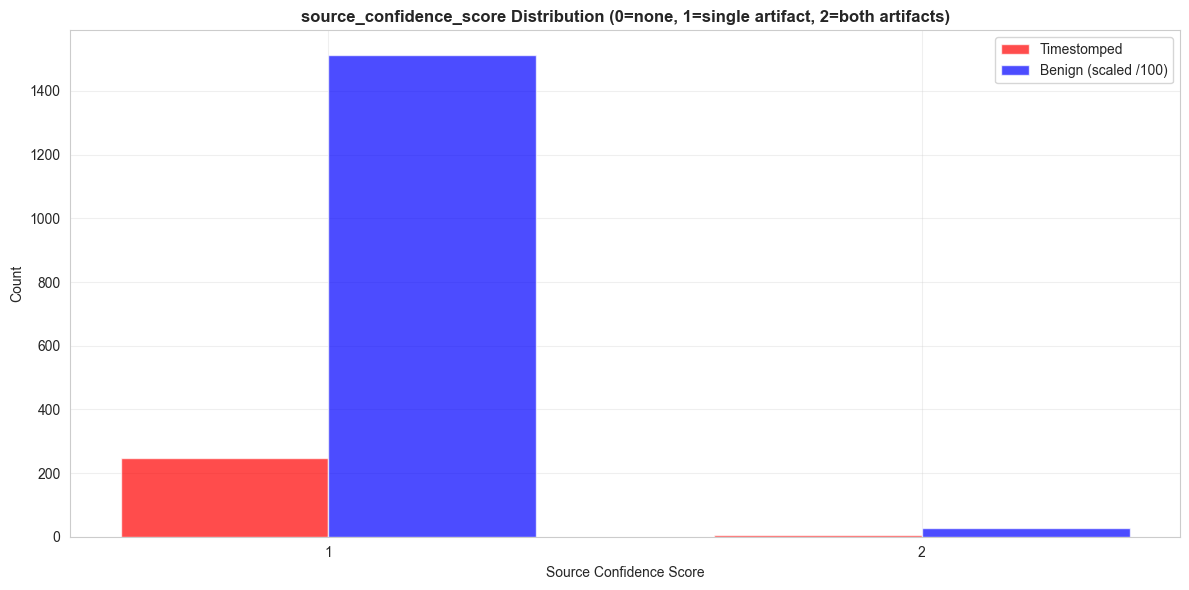


✓ Source confidence distribution plot saved


In [25]:
# Plot 2: source_confidence_score distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Count distribution
ts_conf = df[df['is_timestomped']==1]['source_confidence_score'].value_counts().sort_index()
benign_conf = df[df['is_timestomped']==0]['source_confidence_score'].value_counts().sort_index()

x = np.arange(len(ts_conf))
width = 0.35

ax.bar(x - width/2, ts_conf.values, width, label='Timestomped', color='red', alpha=0.7)
ax.bar(x + width/2, benign_conf.values / 100, width, label='Benign (scaled /100)', color='blue', alpha=0.7)

ax.set_xlabel('Source Confidence Score')
ax.set_ylabel('Count')
ax.set_title('source_confidence_score Distribution (0=none, 1=single artifact, 2=both artifacts)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ts_conf.index)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'source_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Source confidence distribution plot saved")

---
## 8. Save Dataset with Phase 2B Features

In [26]:
print("=" * 80)
print("SAVING DATASET WITH PHASE 2B FEATURES")
print("=" * 80)

# Save output
output_file = OUTPUT_DIR / 'all_cases_combined_with_phase2b_features.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
file_size = output_file.stat().st_size / (1024 * 1024)

print(f"\n✓ Dataset saved:")
print(f"  File: {output_file.name}")
print(f"  Path: {output_file}")
print(f"  Size: {file_size:.2f} MB")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Phase 2B features: {len(new_features_2b)}")
print(f"  Timestomped: {(df['is_timestomped'] == 1).sum()}")

SAVING DATASET WITH PHASE 2B FEATURES

✓ Dataset saved:
  File: all_cases_combined_with_phase2b_features.csv
  Path: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2B - Cross Artifact and Pattern Features/all_cases_combined_with_phase2b_features.csv
  Size: 93.76 MB
  Records: 154,550
  Columns: 63
  Phase 2B features: 7
  Timestomped: 252


---
## 9. Phase 2B Summary Report

In [27]:
print("\n" + "=" * 80)
print("PHASE 2B SUMMARY REPORT")
print("=" * 80)

print("\n✅ PHASE 2B COMPLETE - CROSS-ARTIFACT & PATTERN FEATURES")

print("\n📊 Features Created:")
print(f"\n  Group 2 - Cross-Artifact Correlation (3 features):")
for feat in new_features_2b[:3]:
    print(f"    ✓ {feat}")

print(f"\n  Group 3 - UsnJrnl Pattern Detection (3 features):")
for feat in new_features_2b[3:6]:
    print(f"    ✓ {feat}")

print(f"\n  Group 4 - Event-Time Comparison (1 feature):")
for feat in new_features_2b[6:7]:
    print(f"    ✓ {feat}")

print(f"\n🔧 Bug Fix:")
print(f"    ✓ path_depth corrected (Phase 2A bug)")

print(f"\n📊 Total Feature Engineering Progress:")
print(f"  Phase 1B: 38 columns (baseline)")
print(f"  Phase 2A: +18 columns (file-level + behavioral)")
print(f"  Phase 2B: +7 columns (cross-artifact + patterns)")
print(f"  Total: {len(df.columns)} columns")
print(f"  New features: 25 (18 + 7)")

print(f"\n📊 Dataset Statistics:")
print(f"  Records: {len(df):,} (unchanged)")
print(f"  Timestomped: {(df['is_timestomped'] == 1).sum()} (unchanged)")
print(f"  File size: {file_size:.2f} MB")

print(f"\n📁 Output Files:")
print(f"  Dataset: all_cases_combined_with_phase2b_features.csv ({file_size:.2f} MB)")
print(f"  Plots: phase2b_boolean_features.png")
print(f"  Plots: source_confidence_distribution.png")

print(f"\n🎯 Key Observations:")

# Source confidence analysis
ts_conf_dist = df[df['is_timestomped']==1]['source_confidence_score'].value_counts()
print(f"\n  1. Source Confidence Distribution (Timestomped):")
for score, count in ts_conf_dist.sort_index().items():
    conf_label = {0: 'None', 1: 'Single artifact', 2: 'Both artifacts'}[score]
    print(f"     Score {score} ({conf_label}): {count} / 252 ({count/252*100:.1f}%)")

# UsnJrnl pattern overlap
ts_pattern = df[df['is_timestomped']==1]['usn_complete_manipulation_pattern'].sum()
benign_pattern = df[df['is_timestomped']==0]['usn_complete_manipulation_pattern'].sum()
print(f"\n  2. UsnJrnl Complete Pattern (BASIC_INFO + CLOSE):")
print(f"     Timestomped: {ts_pattern} / 252 ({ts_pattern/252*100:.1f}%)")
print(f"     Benign: {benign_pattern:,} / {len(df[df['is_timestomped']==0]):,} ({benign_pattern/len(df[df['is_timestomped']==0])*100:.2f}%)")
print(f"     Overlap: Pattern appears in BOTH classes (expected, ML will use combinations)")

# Event-time comparison
ts_with_event_time = df[(df['is_timestomped']==1) & (df['event_vs_modified_after_days'].notnull())]
if len(ts_with_event_time) > 0:
    print(f"\n  3. Event-Time vs Modified-Time:")
    print(f"     Timestomped with feature: {len(ts_with_event_time)} / 252 ({len(ts_with_event_time)/252*100:.1f}%)")
    print(f"     Mean delta: {ts_with_event_time['event_vs_modified_after_days'].mean():.2f} days")
    print(f"     Interpretation: Larger deltas = more suspicious")

print("\n" + "=" * 80)
print("✅ READY FOR PHASE 2C: FEATURE QUALITY ANALYSIS & SELECTION")
print("=" * 80)


PHASE 2B SUMMARY REPORT

✅ PHASE 2B COMPLETE - CROSS-ARTIFACT & PATTERN FEATURES

📊 Features Created:

  Group 2 - Cross-Artifact Correlation (3 features):
    ✓ source_confidence_score
    ✓ has_logfile_evidence
    ✓ has_usnjrnl_evidence

  Group 3 - UsnJrnl Pattern Detection (3 features):
    ✓ usn_basic_info_change
    ✓ usn_file_closed
    ✓ usn_complete_manipulation_pattern

  Group 4 - Event-Time Comparison (1 feature):
    ✓ event_vs_modified_after_days

🔧 Bug Fix:
    ✓ path_depth corrected (Phase 2A bug)

📊 Total Feature Engineering Progress:
  Phase 1B: 38 columns (baseline)
  Phase 2A: +18 columns (file-level + behavioral)
  Phase 2B: +7 columns (cross-artifact + patterns)
  Total: 63 columns
  New features: 25 (18 + 7)

📊 Dataset Statistics:
  Records: 154,550 (unchanged)
  Timestomped: 252 (unchanged)
  File size: 93.76 MB

📁 Output Files:
  Dataset: all_cases_combined_with_phase2b_features.csv (93.76 MB)
  Plots: phase2b_boolean_features.png
  Plots: source_confidence_d

---

## Next Steps: Phase 2C - Feature Quality Analysis

**Phase 2C will analyze and select features:**

### 1. Feature Distribution Analysis
- Plot distributions for ALL 25 new features
- Identify features with good separation (timestomped vs benign)
- Visualize feature importance patterns

### 2. Correlation Analysis
- Calculate correlation matrix for all features
- Identify highly correlated features (>0.95)
- Remove redundant features

### 3. Preliminary Feature Importance
- Train baseline Random Forest with ALL features
- Calculate feature importance scores
- Rank features by importance
- Identify top 20-25 features

### 4. Feature Selection
- Remove low-importance features (<1% importance)
- Remove highly correlated features
- Create curated feature set for final modeling

### 5. Documentation
- Feature quality report
- Feature importance rankings
- Feature correlation heatmap
- Recommendations for Phase 3 (baseline model training)

**Expected Output**: Curated dataset with ~20-30 high-quality features ready for Phase 3 model training.

---